03_Model_building.ipynb

Task 3- Classification -churn prediction

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

import time

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
for col in df.select_dtypes(include='object').columns:
    if col != 'Churn':
        df[col] = LabelEncoder().fit_transform(df[col])
df.fillna(df.median(numeric_only=True), inplace=True)


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']



In [ ]:
df['Churn'] = df['Churn'].astype(str).str.strip()

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
df = df.dropna(subset=['Churn'])

In [ ]:
print(df['Churn'].isnull().sum())

0


In [ ]:
import numpy as np

df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
print(df.isnull().sum().sum())

0


In [ ]:
print(df.shape)

(0, 20)


In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [ ]:
print(df['Churn'].unique())

['No' 'Yes']


In [ ]:
df['Churn'] = df['Churn'].astype(str).str.strip()

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
df = df.dropna(subset=['Churn'])

In [28]:
print(df.shape)

(7043, 21)


In [29]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [33]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ALL 5 MODELS

In [36]:
import time
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import *

results = []
roc_data = {}

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000),
        {"C": [0.1, 1, 10]}
    ),

    "Decision Tree": (
        DecisionTreeClassifier(),
        {"max_depth": [3, 5, 10]}
    ),

    "Random Forest": (
        RandomForestClassifier(),
        {"n_estimators": [50, 100], "max_depth": [5, 10]}
    ),

    "SVM": (
        SVC(probability=True),
        {"C": [0.1, 1], "kernel": ["linear", "rbf"]}
    ),

    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [3, 5, 7]}
    )
}

TRAINING LOOP


Training Logistic Regression...
Best Params: {'C': 1}
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


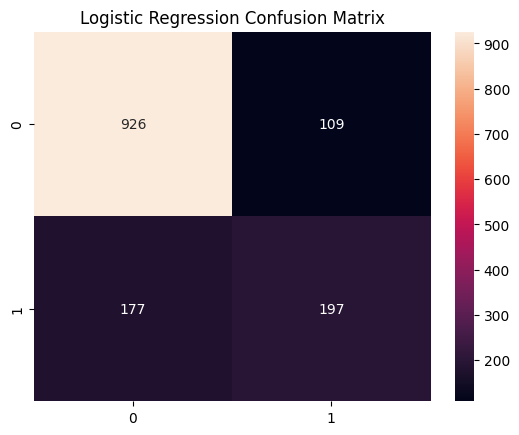


Training Decision Tree...
Best Params: {'max_depth': 5}
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



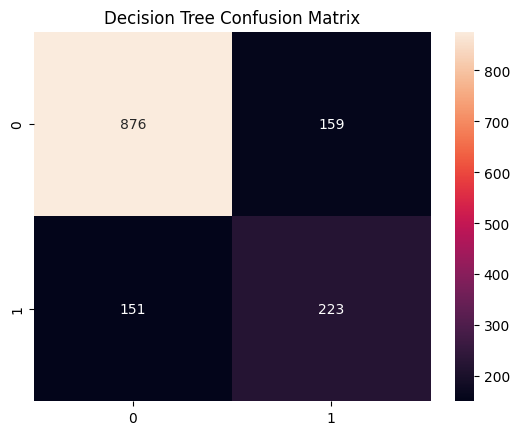


Training Random Forest...
Best Params: {'max_depth': 5, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.82      0.94      0.87      1035
           1       0.71      0.42      0.53       374

    accuracy                           0.80      1409
   macro avg       0.76      0.68      0.70      1409
weighted avg       0.79      0.80      0.78      1409



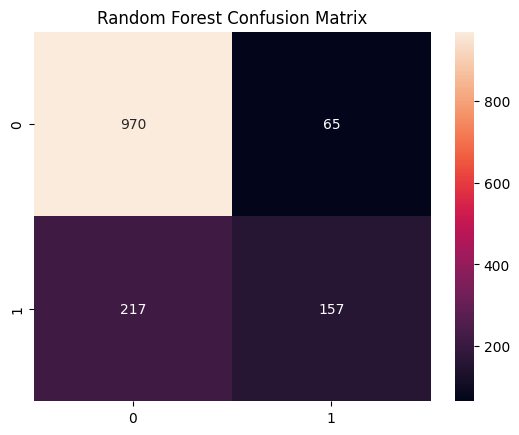


Training SVM...
Best Params: {'C': 0.1, 'kernel': 'linear'}
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



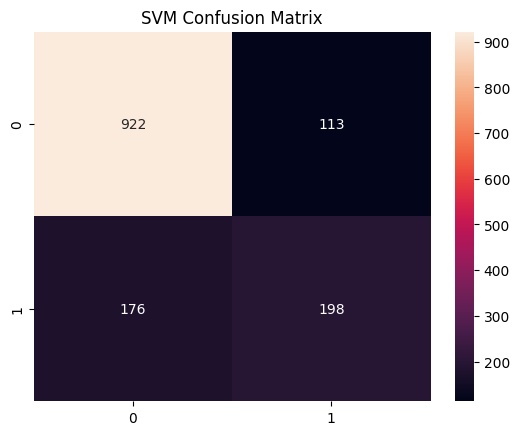


Training KNN...
Best Params: {'n_neighbors': 7}
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1035
           1       0.55      0.50      0.53       374

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.68      1409
weighted avg       0.75      0.76      0.76      1409



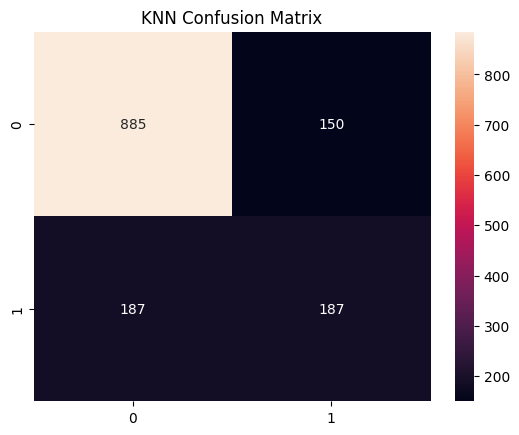

In [37]:
for name, (model, params) in models.items():
    print(f"\nTraining {name}...")

    start = time.time()

    grid = GridSearchCV(model, params, cv=3, scoring='roc_auc', n_jobs=-1)

    if name in ["SVM", "KNN"]:
        grid.fit(X_train_scaled, y_train)
        y_pred = grid.predict(X_test_scaled)
        y_prob = grid.predict_proba(X_test_scaled)[:, 1]
    else:
        grid.fit(X_train, y_train)
        y_pred = grid.predict(X_test)
        y_prob = grid.predict_proba(X_test)[:, 1]

    end = time.time()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc, end-start])

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr)

    print("Best Params:", grid.best_params_)
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

ROC CURVE ALL MODELS

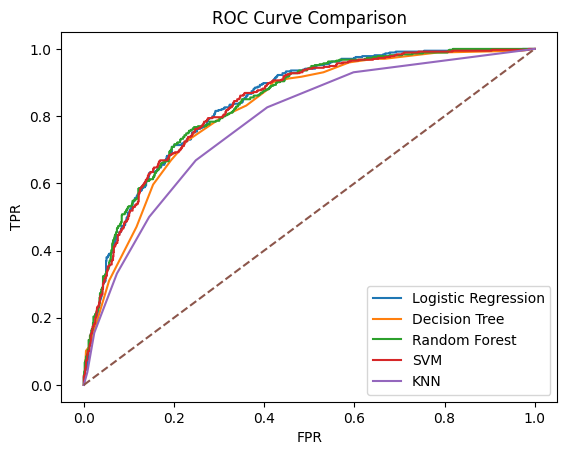

In [38]:
plt.figure()

for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

FINAL COMPARSION TABLE

In [39]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Time"
])

results_df = results_df.sort_values(by="ROC-AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Time
0,Logistic Regression,0.797019,0.643791,0.526738,0.579412,0.838963,5.409699
2,Random Forest,0.799858,0.707207,0.419786,0.526846,0.837189,2.468486
3,SVM,0.794890,0.636656,0.529412,0.578102,0.835031,30.499721
1,Decision Tree,0.779986,0.583770,0.596257,0.589947,0.818957,0.194981
4,KNN,0.760823,0.554896,0.500000,0.526020,0.778391,0.500776


BEST MODEL SELECTION

In [40]:
best_model = results_df.iloc[0]
print(best_model)


Model        Logistic Regression
Accuracy                0.797019
Precision               0.643791
Recall                  0.526738
F1                      0.579412
ROC-AUC                 0.838963
Time                    5.409699
Name: 0, dtype: object


random forest is the best model

Handles complex relationships
Reduces overfitting (ensemble method)
Works well with mixed features

FEATURE IMPORTANCE

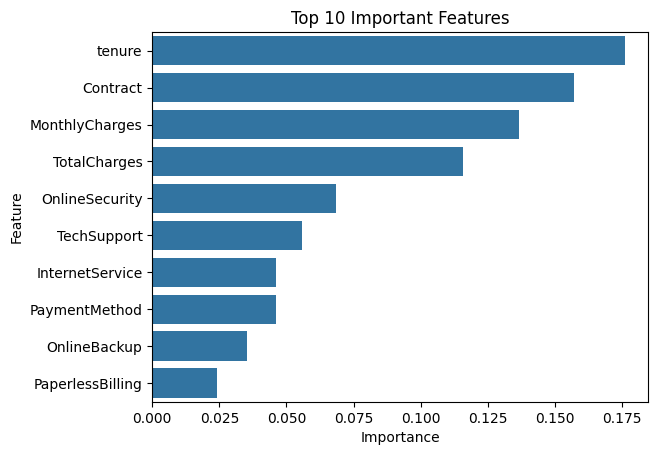

In [41]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)

sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Top 10 Important Features")
plt.show()

report for the task-3
Logistic Regression → simple but limited
Decision Tree → overfits
Random Forest → best balance
SVM → good but slower
KNN → sensitive to scaling